In [1]:
# Adiciona o diretório raiz ao caminho de módulos do Python
import sys
import importlib
from pathlib import Path
sys.path.append(str(Path.cwd().parent))


import pandas as pd
from src.preprocessing.transformations import preparar_dados
from src.modeling.train import split_temporal, treinar_modelos

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from src.evaluation.metrics import prever_com_threshold, plotar_matriz_confusao, relatorio_completo, sweep_thresholds, plotar_sweep_thresholds, comparar_modelos, avaliar_modelo
from src.evaluation.interpretability import importancia_arvore, plotar_importancia, calcular_shap, plotar_shap_summary, plotar_shap_importancia_media
from src.evaluation.risk_aggregation import agregar_risco_por_municipio, filtrar_municipios_relevantes
from src.evaluation.clustering import construir_perfil_municipal, testar_quantidade_clusters, plotar_escolha_k, aplicar_clustering, descrever_clusters, plotar_distribuicao_geografica_clusters
from src.evaluation.meta_trend import construir_tabela_tendencia_meta, resumo_classificacao_risco

In [2]:
CAMINHO_GOLD = r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\data\gold_alfabetizacao.csv"

df = pd.read_csv(CAMINHO_GOLD)
df_preparado = preparar_dados(df)

print(df_preparado.shape)
df_preparado.head()

Registros antes do filtro: 3,867,999
Registros depois do filtro: 3,354,625
Registros removidos: 513,374
(3354625, 11)


,id_aluno,id_municipio,nome_municipio,ano,log_populacao,pct_pes_pob,pct_pes_baixa_renda,pct_pes_acima_meio_sm,rede,uf,alfabetizado
0,12006689,1200807,Porto Acre,2024,9.767439,0.668175,0.140304,0.132168,3,Acre,0
1,41089293,4104204,Campo Largo,2024,11.868472,0.098742,0.079610,0.112674,3,Paraná,0
2,42089700,4219507,Xanxerê,2024,10.900344,0.038048,0.059804,0.084696,3,Santa Catarina,1
3,41058908,4104204,Campo Largo,2024,11.868472,0.098742,0.079610,0.112674,3,Paraná,1
4,35360686,3550308,São Paulo,2024,16.291677,0.132686,0.077836,0.113673,3,São Paulo,1


In [3]:
X_train, X_test, y_train, y_test, chaves_teste = split_temporal(df_preparado)

modelos = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    # "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    # "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    # "Gradient Boosting": HistGradientBoostingClassifier(random_state=42, class_weight="balanced"),
}


pipelines, tempos = treinar_modelos(modelos, X_train, y_train)

Treino (2023): 1,502,809 registros
Teste  (2024): 1,851,816 registros
Treinando: Baseline...
  Concluído em 0min 1.4s (1.4s total)
Treinando: Regressão Logística...
  Concluído em 0min 4.5s (4.5s total)
Treinando: Random Forest...
  Concluído em 1min 20.7s (80.7s total)
Treinando: Gradient Boosting...
  Concluído em 0min 10.5s (10.5s total)

Resumo de tempos de treino:
  Baseline: 1.4s
  Regressão Logística: 4.5s
  Gradient Boosting: 10.5s
  Random Forest: 80.7s


C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   threshold  recall_nao_alfabetizado  precisao_nao_alfabetizado  \
0       0.30                   0.0122                     0.6738   
1       0.35                   0.0486                     0.6586   
2       0.40                   0.0888                     0.6419   
3       0.45                   0.1544                     0.6130   
4       0.50                   0.2413                     0.5773   
5       0.55                   0.3942                     0.5196   
6       0.60                   0.5913                     0.4820   
7       0.65                   0.8175                     0.4499   
8       0.70                   0.9029                     0.4341   

   recall_alfabetizado  precisao_alfabetizado  acuracia  f1_macro  
0               0.9960                 0.5998    0.6004    0.3864  
1               0.9831                 0.6057    0.6072    0.4200  
2               0.9667                 0.6120    0.6136    0.4528  
3               0.9344                 0.6216  

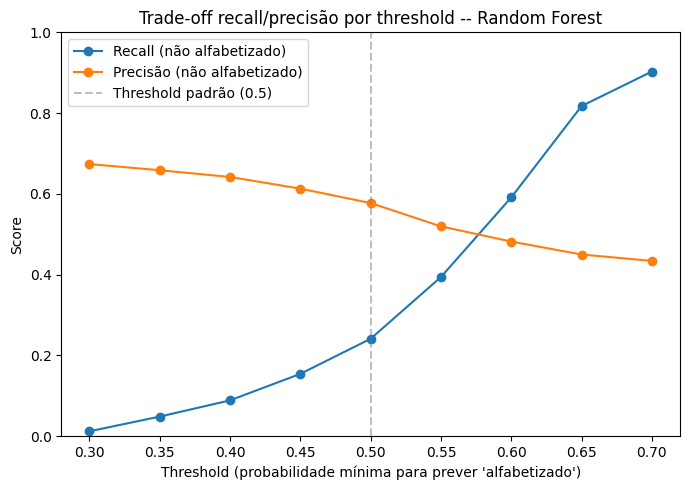

In [4]:
tabela_sweep = sweep_thresholds(pipelines["Random Forest"], X_test, y_test)
print(tabela_sweep)

plotar_sweep_thresholds(tabela_sweep, "Random Forest",
                         caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\sweep_threshold_rf.png")

## Avaliação

In [5]:
tabela_comparativa = comparar_modelos(pipelines, X_test, y_test)
print(tabela_comparativa)

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as

                     acuracia  precisao  recall      f1  roc_auc
Random Forest          0.6238    0.6332  0.8812  0.7369   0.6258
Gradient Boosting      0.6241    0.6327  0.8851  0.7379   0.6240
Regressão Logística    0.6116    0.6347  0.8253  0.7176   0.6179
Baseline               0.5978    0.5978  1.0000  0.7483   0.5000


In [6]:
tirando_os_3_estados = ~df_preparado.loc[X_test.index, "uf"].isin(['Distrito Federal', 'Acre', 'São Paulo'])

print(f"Registros no teste completo: {len(X_test):,}")
print(f"Registros sem SP/DF/AC: {tirando_os_3_estados.sum():,}")
print(f"Registros removidos: {(~tirando_os_3_estados).sum():,}")

metricas_completo = avaliar_modelo(pipelines["Random Forest"], X_test, y_test)
metricas_sem_novos_estados = avaliar_modelo(
    pipelines["Random Forest"], X_test[tirando_os_3_estados], y_test[tirando_os_3_estados]
)

print("\nTeste completo:", metricas_completo)
print("Teste sem SP/DF/AC:", metricas_sem_novos_estados)

Registros no teste completo: 1,851,816
Registros sem SP/DF/AC: 1,424,027
Registros removidos: 427,789


C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Teste completo: {'acuracia': 0.623829257334422, 'precisao': 0.633230124110713, 'recall': 0.8811594647984775, 'f1': 0.7368998325689468, 'roc_auc': np.float64(0.6258180967650249)}
Teste sem SP/DF/AC: {'acuracia': 0.6354696926392547, 'precisao': 0.6513467303288166, 'recall': 0.8485258977159232, 'f1': 0.7369753387620384, 'roc_auc': np.float64(0.646585877997938)}


C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


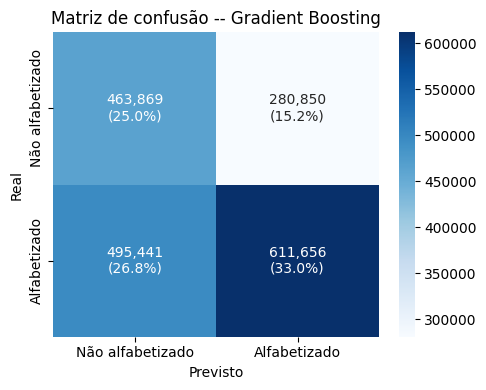

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Relatório de classificação -- Gradient Boosting (threshold=0.6)
                  precision    recall  f1-score   support

Não alfabetizado       0.48      0.62      0.54    744719
    Alfabetizado       0.69      0.55      0.61   1107097

        accuracy                           0.58   1851816
       macro avg       0.58      0.59      0.58   1851816
    weighted avg       0.60      0.58      0.58   1851816



In [7]:
plotar_matriz_confusao(pipelines["Gradient Boosting"], X_test, y_test, "Gradient Boosting",
                        caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\matriz_confusao_gb.png")

relatorio_completo(pipelines["Gradient Boosting"], X_test, y_test, "Gradient Boosting")

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


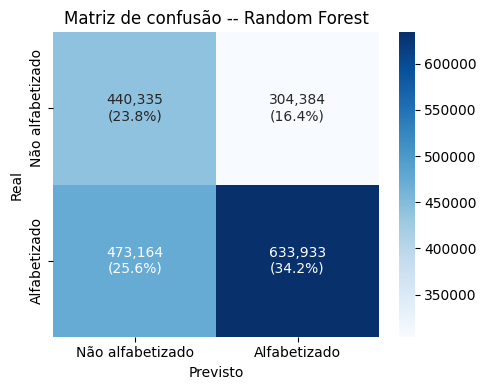

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Relatório de classificação -- Random Forest (threshold=0.6)
                  precision    recall  f1-score   support

Não alfabetizado       0.48      0.59      0.53    744719
    Alfabetizado       0.68      0.57      0.62   1107097

        accuracy                           0.58   1851816
       macro avg       0.58      0.58      0.58   1851816
    weighted avg       0.60      0.58      0.58   1851816



In [8]:
plotar_matriz_confusao(pipelines["Random Forest"], X_test, y_test, "Random Forest",
                        caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\matriz_confusao_rf.png")

relatorio_completo(pipelines["Random Forest"], X_test, y_test, "Random Forest")

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


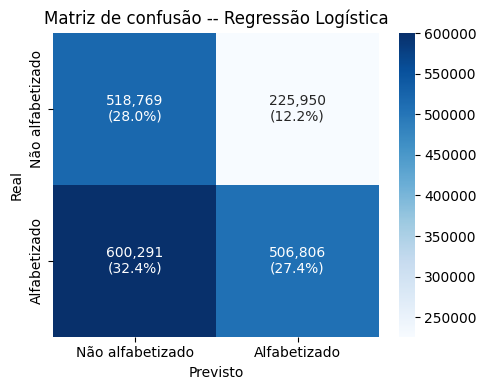

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Relatório de classificação -- Regressão Logística (threshold=0.6)
                  precision    recall  f1-score   support

Não alfabetizado       0.46      0.70      0.56    744719
    Alfabetizado       0.69      0.46      0.55   1107097

        accuracy                           0.55   1851816
       macro avg       0.58      0.58      0.55   1851816
    weighted avg       0.60      0.55      0.55   1851816



In [9]:
plotar_matriz_confusao(pipelines["Regressão Logística"], X_test, y_test, "Regressão Logística",
                        caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\matriz_confusao_rl.png")

relatorio_completo(pipelines["Regressão Logística"], X_test, y_test, "Regressão Logística")

                        feature  importancia
0              num__pct_pes_pob     0.173663
1                 cat__uf_Ceará     0.162833
2            num__log_populacao     0.128722
3      num__pct_pes_baixa_renda     0.114600
4    num__pct_pes_acima_meio_sm     0.112411
5                 cat__uf_Bahia     0.096266
6                cat__uf_Paraná     0.044129
7               cat__uf_Sergipe     0.024414
8                   cat__rede_3     0.018413
9   cat__uf_Rio Grande do Norte     0.017604
10                cat__uf_Goiás     0.011564
11   cat__uf_Mato Grosso do Sul     0.011299
12            cat__uf_Tocantins     0.009093
13                 cat__uf_Pará     0.009040
14       cat__uf_Espírito Santo     0.008933
15         cat__uf_Minas Gerais     0.008767
16             cat__uf_Maranhão     0.008122
17           cat__uf_Pernambuco     0.007770
18    cat__uf_Rio Grande do Sul     0.006511
19          cat__uf_Mato Grosso     0.004360
20       cat__uf_Rio de Janeiro     0.004273
21        

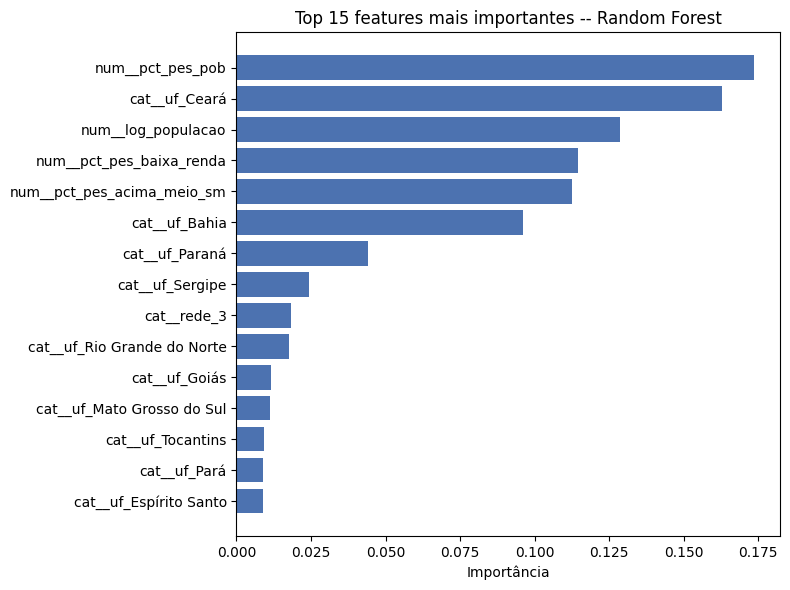

In [10]:
tabela_imp = importancia_arvore(pipelines["Random Forest"], "Random Forest")
print(tabela_imp)

plotar_importancia(tabela_imp, "Random Forest",
                    caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\feature_importance_rf.png")

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


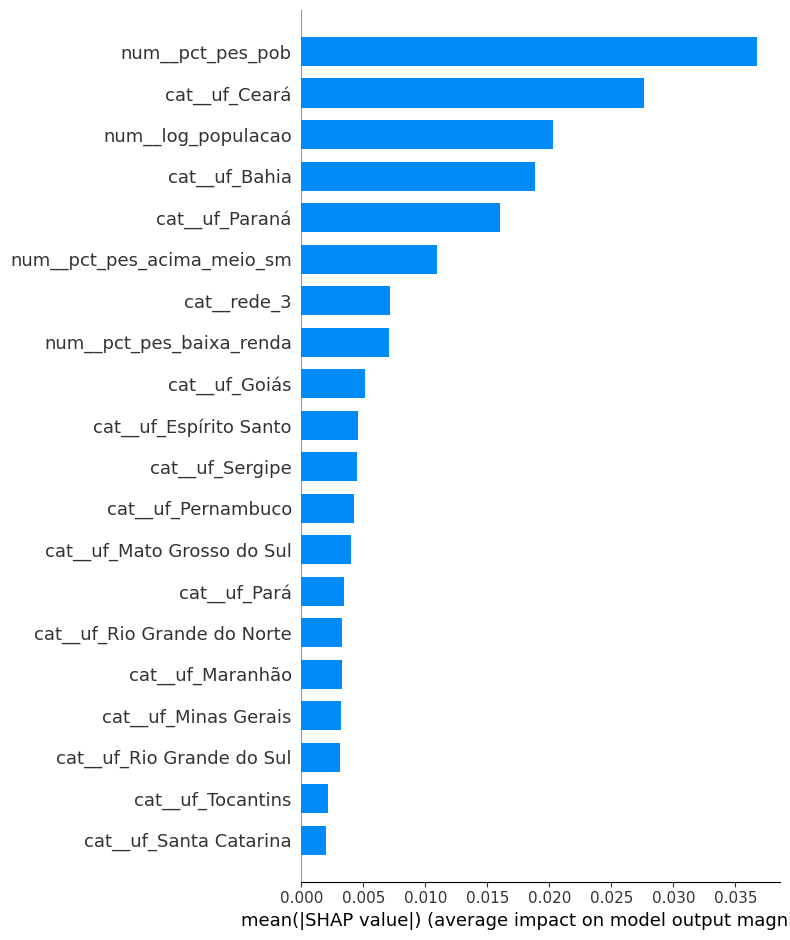

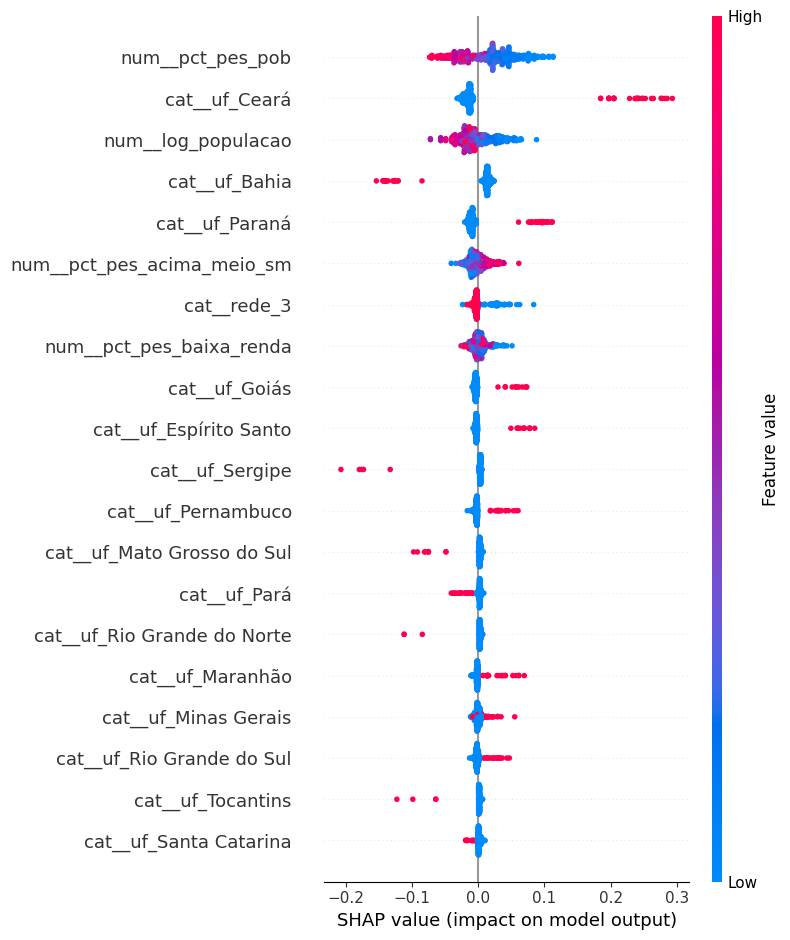

In [11]:
shap_values, X_transformado = calcular_shap(pipelines["Random Forest"], X_test, tamanho_amostra=500)


plotar_shap_importancia_media(shap_values, X_transformado,
    caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\shap_importancia_media_rf.png")


plotar_shap_summary(shap_values, X_transformado,
    caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\shap_summary_rf.png")

In [4]:
tabela_risco = agregar_risco_por_municipio(pipelines["Random Forest"], X_test, chaves_teste, df_preparado)
tabela_risco_confiavel = filtrar_municipios_relevantes(tabela_risco, minimo_alunos=100)

print(tabela_risco_confiavel["categoria_risco"].value_counts())
print(tabela_risco_confiavel.head(20))

C:\Users\dieizon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


categoria_risco
Sem risco (nenhum aluno)                1505
Risco generalizado (todos os alunos)    1241
Risco misto (depende da rede)            178
Name: count, dtype: int64
    id_municipio            nome_municipio                   uf  \
0        2803609               Laranjeiras              Sergipe   
1        2805307                   Pirambu              Sergipe   
2        2805802         Riachão do Dantas              Sergipe   
3        2805406              Poço Redondo              Sergipe   
4        2806305     Santa Luzia do Itanhy              Sergipe   
5        2414209              Tibau do Sul  Rio Grande do Norte   
6        2800407                     Arauá              Sergipe   
7        2804805  Nossa Senhora do Socorro              Sergipe   
8        2927309      Salinas da Margarida                Bahia   
9        2803203        Itaporanga d'Ajuda              Sergipe   
10       2924207           Pedro Alexandre                Bahia   
11       2804003   

(5547, 9)
    k       inercia  silhouette
0   2  21009.466949    0.217965
1   3  16472.384286    0.247553
2   4  14449.957328    0.226557
3   5  12861.017612    0.228730
4   6  11726.205783    0.219294
5   7  10782.690470    0.214649
6   8  10154.236280    0.202275
7   9   9658.976170    0.193790
8  10   9157.295736    0.190016


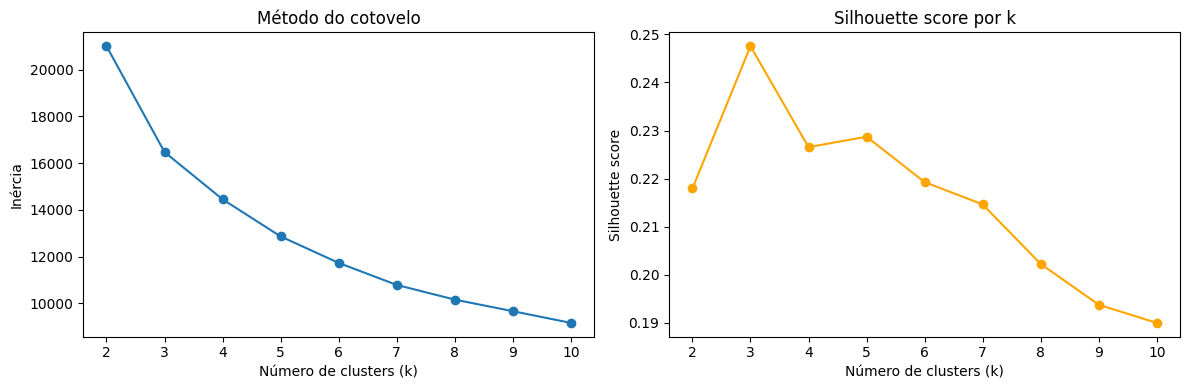

In [7]:
perfil = construir_perfil_municipal(df_preparado)
print(perfil.shape)

tabela_k = testar_quantidade_clusters(perfil, k_min=2, k_max=10)
print(tabela_k)

plotar_escolha_k(tabela_k,
                  caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\clustering_escolha_k.png")

         taxa_alfabetizacao  pct_pes_pob  pct_pes_baixa_renda  \
cluster                                                         
0                     0.468        0.516                0.127   
1                     0.667        0.153                0.092   
2                     0.715        0.269                0.156   

         pct_pes_acima_meio_sm  log_populacao  qtd_municipios  
cluster                                                        
0                        0.129          9.660            1723  
1                        0.115         10.106            1730  
2                        0.204          8.759            2094  


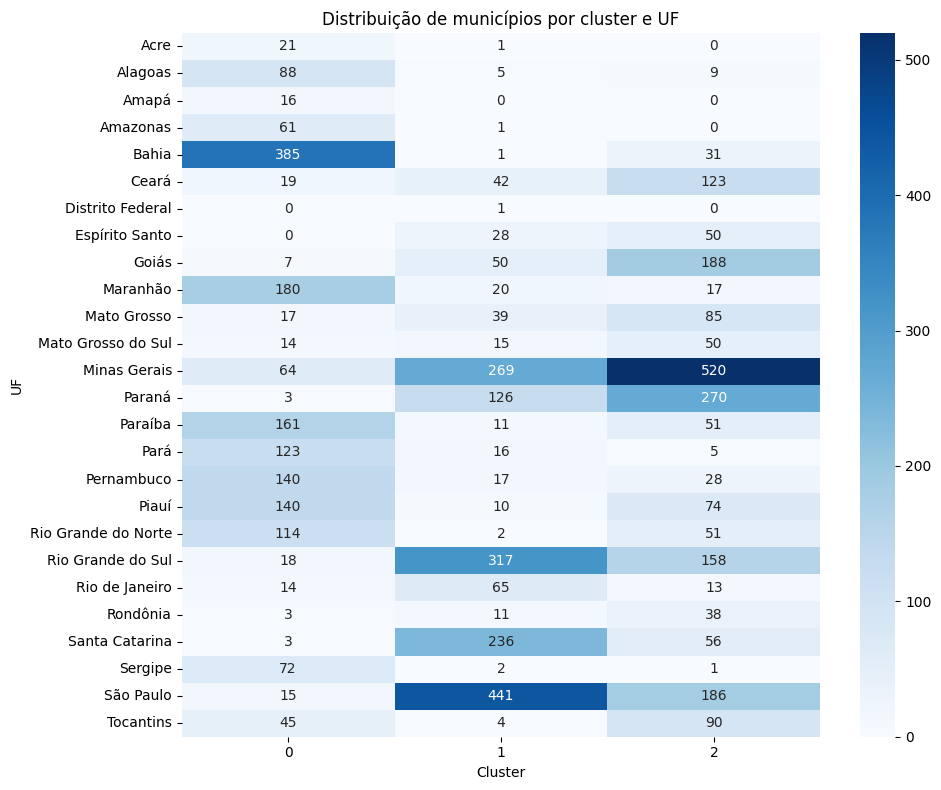

In [9]:
perfil_com_cluster = aplicar_clustering(perfil, k=3)

resumo_clusters = descrever_clusters(perfil_com_cluster)
print(resumo_clusters)

plotar_distribuicao_geografica_clusters(perfil_com_cluster,
    caminho_saida=r"E:\POS_GRADUACAO\FASE3_V2\tech_challenge_fase3\reports\images\clusters_por_uf.png")

In [10]:
tabela_tendencia = construir_tabela_tendencia_meta(df, minimo_alunos_por_ano=100)

resumo = resumo_classificacao_risco(tabela_tendencia)
print(resumo)

print("\nMunicípios com maior risco (ritmo muito lento ou estagnado):")
print(tabela_tendencia[tabela_tendencia["classificacao_risco"].str.contains("Risco alto")].head(20))

                   classificacao_risco  qtd_municipios   pct
0                    Já superou a meta             978  40.3
1   Risco alto (estagnado ou piorando)             880  36.3
2       No ritmo (deve atingir a meta)             267  11.0
3       Risco alto (ritmo muito lento)             193   8.0
4  Risco moderado (ritmo insuficiente)             108   4.5

Municípios com maior risco (ritmo muito lento ou estagnado):
    id_municipio  nome_municipio                   uf  qtd_alunos_2023  \
0        2509057        Marcação              Paraíba            123.0   
1        2100808        Anapurus             Maranhão            179.0   
2        4313953  Pantano Grande    Rio Grande do Sul            103.0   
3        2106607          Matões             Maranhão            289.0   
4        2112605   Urbano Santos             Maranhão            299.0   
5        2108801       Pirapemas             Maranhão            135.0   
6        1302553       Manaquiri             Amazonas 

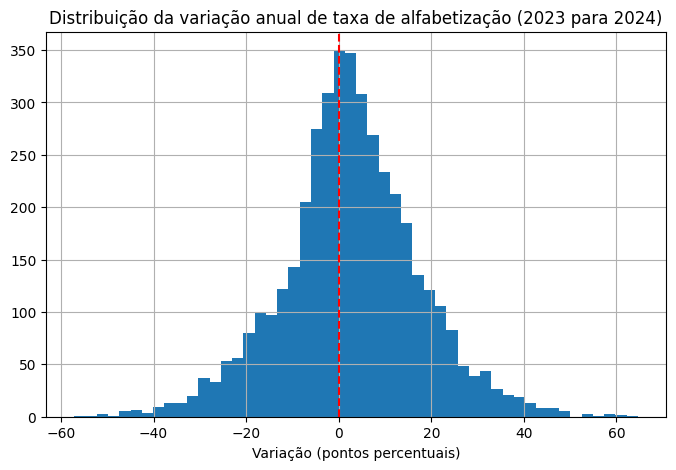

count    4177.000000
mean        2.666656
std        14.919834
min       -57.116498
25%        -5.638692
50%         2.389553
75%        11.538462
max        64.627451
Name: variacao_anual, dtype: float64


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
tabela_tendencia["variacao_anual"].hist(bins=50)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribuição da variação anual de taxa de alfabetização (2023 para 2024)")
plt.xlabel("Variação (pontos percentuais)")
plt.show()

print(tabela_tendencia["variacao_anual"].describe())

In [8]:
# Verificar se algum desses municípios mudou de rede predominante entre os anos
municipios_suspeitos = tabela_tendencia[tabela_tendencia["variacao_anual"] < -30]["id_municipio"]

rede_por_ano = df[df["id_municipio"].isin(municipios_suspeitos)].groupby(["id_municipio", "ano"])["rede"].agg(lambda x: x.value_counts().index[0])
print(rede_por_ano)

id_municipio  ano 
1713601       2023    3
              2024    3
2100709       2023    3
              2024    3
2100808       2023    3
                     ..
4322541       2024    3
5005681       2023    3
              2024    3
5100359       2023    3
              2024    3
Name: rede, Length: 162, dtype: int64
